# 데이터 전처리
- 데이터를 분석하기 좋은 형태로 가공하는 과정이다.
- 원본 데이터를 그대로 사용하는 것이 아니라
    이상치, 중복데이터, 결속치 등을 처리해서 신뢰할 수 았는 데이터로 만드는 고정을 의미한다.

##  이상치(outlier)
- 관속하거나 수집한 데이터의 범위(군집)에서 많이 벗어나있는 아주작은 값 또는 큰 값을 의미한다.
- 이상치는 제거하거나 대체하거나 또는 가만히 놔두어도 상관없는지를 판단하여 전처리를 진행해야한다.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuY-LwTufVlKJ-r54472gZtIxK7CuP0Ei6gVwSRUy8zWdl1koZIG6VzpR6&s=10" />

## 예측
- 숫자로 알기 힘든 값들을 표현하기위해 기술통계랑을 확인하는 것을 의미한다.
- min(최소), max(최대), median(최빈), mean(평균)

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [52]:
# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [53]:
height_list = [181, 280, 158, 110, 170, 160, 155, 146]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키:{avg_height}cm")
print(f"최소 키:{min(height_list)}cm")
print(f"최대 키: {max(height_list)}cm")

평균 키:170.0cm
최소 키:110cm
최대 키: 280cm


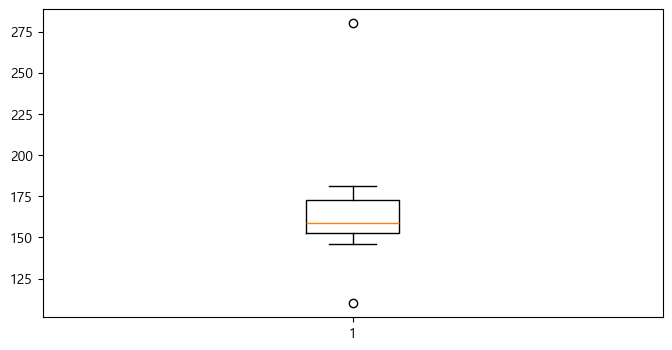

In [54]:
plt.figure(figsize=(8, 4))

# 박스플롯 이상치 탐지
plt.boxplot(height_list)
plt.show()

## 박스 플롯
- 이상치 탐색을위해 사용되는 시각화 차트이다
- 분위수를 기준으로 그려지고 상자안에 그러져 있는 직선이 중위수(Median)을 나타낸다 meaian의 값의 위치에 따라 값들의 분포를 확인할 수 있따
- 상자의 밑변은 1분위수이고, 윗변은 3분위수를 의미한다
- 상자의 중심으로 위 아래에 직선이 있는 것을 볼 수 있는데 이것을 울타리라고 부른다.

## 이상치 계산공식
- 아래 이상치 공식 Q1 - (1.5 * IQR)     - > Q1: 25% 하위 일분위
- 위 이상치 공식 Q3 + (1.5 * IQR)        -> Q3: 75% 상위 삼분위

<img style="width:500px;" src="https://blog.kakaocdn.net/dna/dLPevN/btq1caAZMWD/AAAAAAAAAAAAAAAAAAAAACdUyXIwIBA0UI-lNOxgEND-ivrCO7oAkDQNWYlbYDTf/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=o4DIu2hQNUV89WOVQAkr5VNdrvg%3D" />

In [55]:
height_list = [181, 158, 170, 160, 155, 146]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키:{avg_height}cm")
print(f"최소 키:{min(height_list)}cm")
print(f"최대 키: {max(height_list)}cm")

평균 키:161.66666666666666cm
최소 키:146cm
최대 키: 181cm


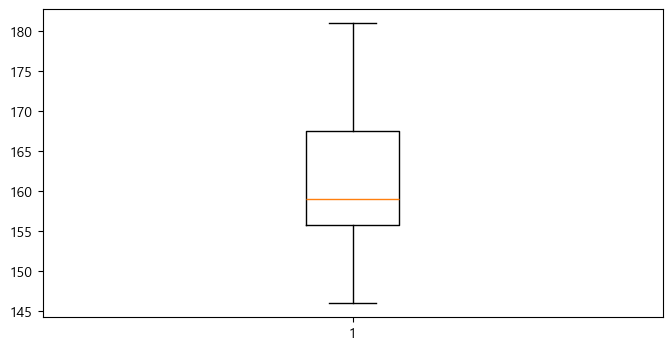

In [56]:
plt.figure(figsize=(8, 4))

# 박스플롯 이상치 탐지
plt.boxplot(height_list)
plt.show()

## 이상치 (outlier) 처리방법
1. 값을 그대로 냅둔다.
2. 값을 제거 하는 방법 (신뢰도 저하, 데이터 버려지는 단점이 있다 -> 값을 많이 제거해버려서 일반화가 됨)

## 결측치 (outlier) 처리방법
- 데이터 수집 또는 데이터 셋에서 NULL, NaN 값이 들어가 비어있는 상태를 의미한다
- 데이터를 수집하는 과정에서 오류, 누락, 값을 저장하는 과정해서 소실한 것을 의미하여 분석전에 반드시 처리해야한다
- 대체한다면 평균값 최빈값 중앙값 같은 통계수치나 머신러닝의 에측 값 중 적절한 데이터의 특성을 고려하여 대체 해야한다

![](https://drive.google.com/thumbnail?id=1Xu3g-0MJOJxcXr330-JecGN_nI7Yqoos&sz=w1000)

In [57]:
df = pd.DataFrame({
    "이름": ["시츄", "하아", "승연", "지성", "혜지", "승기", "우연", "소민"],
    "소득": [1000000, 5500, None, None, 100000, 50000, 3000, 50000]
})

df

,이름,소득
0,시츄,1000000.0
1,하아,5500.0
2,승연,NaN
3,지성,NaN
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [58]:
df.isna().sum()

이름    0
소득    2
dtype: int64

In [59]:
# 결측치 삭제
df.dropna()

,이름,소득
0,시츄,1000000.0
1,하아,5500.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [60]:
# 평균 구하기

## 최빈값: mode()

In [61]:
df.fillna(df["소득"].mode()[0])

,이름,소득
0,시츄,1000000.0
1,하아,5500.0
2,승연,50000.0
3,지성,50000.0
4,혜지,100000.0
5,승기,50000.0
6,우연,3000.0
7,소민,50000.0


In [62]:
plt.figure(figsize=(6,4))
plt.boxplot(df2["소득"])

plt.show()

KeyError: '소득'

<Figure size 600x400 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df.dropna()["소득"])

plt.show()

## 중간값: .median()

In [ ]:
df["소득"].median()

In [ ]:
df.fillna(df["소득"].median())

## 중복 데이터
- 동일한 데이터가 여러번 저장된 상태를 의미
- 중복 데이터가 많아지면 통꼐결과와 왜곡된 분석결과 및 신뢰도가 떨어질 수 있습니다.
<img src="https://drive.google.com/thumbnail?id=1OyllE-RqUt-47NRgJ0N2oyXHKrvic3db&sz=w1000" width=1000>

In [ ]:
df = pd.DataFrame({
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

In [ ]:
df.duplicated().sum()

In [ ]:
df2 = df.drop_duplicates()
df2 

In [ ]:
df = pd.DataFrame({
    "학번": [i + 1 for i in range(10)],
    "이름": ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미": ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})

df

In [ ]:
df.duplicated(subset=["이름","취미"])
df

In [ ]:
# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [69]:
import os

base_path = r"C:\kdt_0900_lsu\data_analysis\resource\dataset"
file_name = r"preprocessing.csv.csv"
file_path = os.path.join(base_path, file_name)

In [84]:
df1 = pd.read_csv(file_path, encoding="cp949", sep="\t")
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [86]:
import os

base_path = r"C:\kdt_0900_lsu\data_analysis\resource\dataset"
file_name = r"preprocessing.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

C:\kdt_0900_lsu\data_analysis\resource\dataset\preprocessing.csv
True


## 1단계: 컬럼 타입 확인
- 각 컬럼이 수지형인지, 범주형/분류형인지 확인해야한다
- 그 이유는 대체값 전략이 달라기지 때문이다
  1. 수치형 데이터: 평균값 또는 중앙값 또는 특정 값으로 대체
  2. 범주형 데이터: 최빈값, 범주 추기하여 처리

In [87]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      30 non-null     int64  
 1   name    30 non-null     object 
 2   age     29 non-null     float64
 3   gender  30 non-null     object 
 4   city    29 non-null     object 
 5   salary  29 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.5+ KB


In [88]:
# 기술통계랑 
df1.describe()

,id,age,salary
count,30.000000,29.000000,29.000000
mean,15.500000,62.413793,38237.896552
std,8.803408,180.348575,184974.502563
min,1.000000,-5.000000,2700.000000
25%,8.250000,26.000000,3400.000000
50%,15.500000,29.000000,3700.000000
75%,22.750000,34.000000,4500.000000
max,30.000000,999.000000,999999.000000


## 2단계, 각 컬럼 타입의 계획수립
- id: int - 분류형
- name: str- 분류형
- age: float -> int -수치형
- gender: str - 분류형
- city: str - 분류형
- salary  -수치형

## 3단계 

In [91]:
# age, city, salary : 결측치가 있다
df1.isna().sum()

id        0
name      0
age       1
gender    0
city      1
salary    1
dtype: int64

In [90]:
#age에는 이상치가 있다
plt.boxlot(df1["age"].dropna())
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'boxlot'

## 4단계, 결측치 내제

In [92]:
# age, city, salary: 결측치가 있다.
# age: 수치형 
# - 중앙값(median)
age_median = df1["age"].median()
df1["age"] = df1["age"].fillna(age_median)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [93]:
# 분류형 -> 중앙값이 없기에 최빈값이나 새로운 컬럼을 만들어서 넣는 방법이 있음

city_mode = df1["city"].mode()[0]
city_mode

'서울'

In [94]:
df1["city"] = df1.fillna(city_mode)

ValueError: Columns must be same length as key

In [95]:
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [96]:
# salary 대체값 찾기



## 컬럼의 형변환

In [97]:
df1["age"] = df1["age"].astype(int)
df1["salary"] = df1["salary"].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## 5단계, 이상치 대체 또는 제거

In [99]:
Q1 = df1["salary"].quantile(0.25)
Q3 = df1["salary"].quantile(0.25)

print(f"1사분위 값: {Q1}")
print(f"3사분위 값: {Q3}")
print(f"{IQR}")

1사분위 값: 3400.0
3사분위 값: 3400.0


NameError: name 'IQR' is not defined

In [103]:
min_outlier = Q1 - (IQR * 1.5)
max_outlier = Q3 + (IQR * 1.5)

print(f"max outlier: {max_outlier} 초과")
print(f"min outlier: {min_outlier} 이하")

NameError: name 'IQR' is not defined

In [ ]:
outlier_mask = (df1["salary"] > max_outlier) | (df1["salary"] < min_outlier)
df1["salary"][outlier_mask]

In [100]:
def find_outlier(df, col_name):
    df_copy = df.copy()
    
    Q1 = df1["salary"].quantile(0.25)
    Q3 = df1["salary"].quantile(0.25)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upwer = Q3 - (1.5 * IQR)

    mask = ~((df_copy[col_name] < lower) | (df_copy[col_name] > upwer))
        return df_copy[mask]

In [104]:
def remove_outlier(df, col_name):
    df_copy = df.copy()
    Q1 = df_copy[col_name].quantile(0.25)
    Q3 = df_copy[col_name].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name] < lower) | (df_copy[col_name] > upper))
    return df_copy[mask]

In [102]:
df2 = remove_outlier(df1, "salary")
df3 = remove_outlier(df2, "age")

NameError: name 'remove_outlier' is not defined

# 중복값 삭제

In [105]:
# df4.duplicated(subset=["name", "age", "gender", "city"])
df5 = df4.drop_duplicates(subset=["name", "age", "gender", "city"]).reset_index(drop=True)
df5

NameError: name 'df4' is not defined